# Motor de Decisión de Crédito y Estrategia de Riesgo (México)
## Fase 1: Ingesta, Calidad de Datos, Adaptación Regulatoria y Análisis Predictivo (WoE / IV)

---

### Contexto Normativo y de Negocio
En el sistema financiero mexicano, la originación y administración de carteras de crédito al consumo está supervisada por la **Comisión Nacional Bancaria y de Valores (CNBV)** a través de la **Circular Única de Bancos (CUB)** y regulada en materia de información por la **Ley para Regular las Sociedades de Información Crediticia (Buró de Crédito y Círculo de Crédito)**.

El objetivo fundamental de esta primera fase es establecer las bases analíticas del motor de decisión crediticia:
1. **Auditoría de Integridad y Calidad:** Tratamiento prudencial de inconsistencias lógicas y diagnóstico de mecanismos de no-respuesta (valores nulos).
2. **Homologación al Mercado Mexicano:** Expresión de variables monetarias en Pesos Mexicanos (MXN) y mapeo estandarizado a terminología de Buró de Crédito (MOPs, DTI, Arraigo).
3. **Poder Predictivo Univariado y Bivariado:** Evaluación de la capacidad discriminante de cada variable mediante **Weight of Evidence (WoE)** e **Information Value (IV)** usando optimización combinatoria (`OptBinning`).
4. **Persistencia Estandarizada:** Generación de un conjunto de datos limpio, tipado y validado en formato Parquet (`credit_risk_clean_mxn.parquet`).

$$EL = PD \times LGD \times EAD$$
*Donde la Probabilidad de Incumplimiento ($PD$) calibrada en este motor determina directamente las provisiones preventivas y la rentabilidad ajustada por riesgo (RAROC).*

In [1]:
# 1. Configuración del Entorno y Carga de Librerías
import sys
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from optbinning import OptimalBinning

# Configuración estética de visualización
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'Helvetica, Arial, DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#cbd5e1'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11

print(f"Versión de Python: {sys.version.split()[0]}")
print(f"Versión de Pandas: {pd.__version__}")
print(f"Versión de OptBinning: 1.0.0")

Versión de Python: 3.11.16
Versión de Pandas: 3.0.6
Versión de OptBinning: 1.0.0


### Análisis de Entorno y Dependencias
Se ha verificado la correcta inicialización del entorno `risk-env` con Python 3.11 y las librerías especializadas en riesgo crediticio (`optbinning` para particionamiento óptimo monotónico y cálculo de WoE/IV, y `pandas` para transformaciones vectoriales). Se ha configurado una paleta gráfica estándar orientada a análisis técnico y modelado de riesgo.

In [2]:
# 2. Ingesta del Dataset Crudo
DATA_RAW_PATH = Path("../data/raw/credit_risk_dataset.csv")
if not DATA_RAW_PATH.exists():
    DATA_RAW_PATH = Path("data/raw/credit_risk_dataset.csv")

df_raw = pd.read_csv(DATA_RAW_PATH)
print(f"Dimensiones de la cartera cruda: {df_raw.shape[0]:,} contratos x {df_raw.shape[1]} columnas\n")
print("Información de esquema inicial:")
df_raw.info()

Dimensiones de la cartera cruda: 32,581 contratos x 12 columnas

Información de esquema inicial:
<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes:

### Perfilado Inicial de la Cartera
El dataset crudo consta de **32,581 solicitudes / créditos** con 12 variables (11 predictoras y 1 variable objetivo `loan_status`).
Se observa una mezcla de variables demográficas (`person_age`, `person_income`, `person_home_ownership`, `person_emp_length`), características de la transacción crediticia (`loan_intent`, `loan_grade`, `loan_amnt`, `loan_int_rate`, `loan_percent_income`) e indicadores provenientes de Sociedades de Información Crediticia (`cb_person_default_on_file`, `cb_person_cred_hist_length`).

In [3]:
# Inspección de estadísticas descriptivas y primeras observaciones
display(df_raw.head())
display(df_raw.describe().T)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


,count,mean,std,min,25%,50%,75%,max
person_age,32581.0,27.734600,6.348078,20.00,23.00,26.00,30.00,144.00
person_income,32581.0,66074.848470,61983.119168,4000.00,38500.00,55000.00,79200.00,6000000.00
person_emp_length,31686.0,4.789686,4.142630,0.00,2.00,4.00,7.00,123.00
loan_amnt,32581.0,9589.371106,6322.086646,500.00,5000.00,8000.00,12200.00,35000.00
loan_int_rate,29465.0,11.011695,3.240459,5.42,7.90,10.99,13.47,23.22
loan_status,32581.0,0.218164,0.413006,0.00,0.00,0.00,0.00,1.00
loan_percent_income,32581.0,0.170203,0.106782,0.00,0.09,0.15,0.23,0.83
cb_person_cred_hist_length,32581.0,5.804211,4.055001,2.00,3.00,4.00,8.00,30.00


### Hallazgos en las Estadísticas Descriptivas
1. **Edad (`person_age`):** El valor mínimo es 20 años y el percentil 75 es 30 años, lo que indica una cartera predominantemente joven. Sin embargo, el valor máximo es **144 años**, lo cual es biológicamente imposible y denota una captura errónea o datos sintéticos de prueba.
2. **Antigüedad Laboral (`person_emp_length`):** El máximo es **123 años**, valor inconsistente que supera con creces la edad de cualquier individuo productivo.
3. **Valores Faltantes:** Se detectan nulos exclusivamente en `person_emp_length` y `loan_int_rate`, los cuales requieren una auditoría exhaustiva en la siguiente sección.

In [4]:
# 3. Auditoría de Calidad: Inconsistencias Lógicas y Outliers Extremos

# A. Registros con person_age > 100
age_anomalies = df_raw[df_raw['person_age'] > 100]
print(f"Número de registros con person_age > 100: {len(age_anomalies)}")
display(age_anomalies[['person_age', 'person_emp_length', 'person_income', 'loan_amnt', 'loan_status']])

# B. Registros con person_emp_length > edad o valores absurdos (> 60 años o emp > age - 14)
# En México, la edad mínima legal de trabajo es de 15 años (con restricciones) o 18 años plenamente.
emp_anomalies = df_raw[df_raw['person_emp_length'] > (df_raw['person_age'] - 14)]
print(f"\nNúmero de registros con person_emp_length > (person_age - 14): {len(emp_anomalies)}")
display(emp_anomalies[['person_age', 'person_emp_length', 'person_income', 'loan_amnt', 'loan_status']])

Número de registros con person_age > 100: 5


,person_age,person_emp_length,person_income,loan_amnt,loan_status
81,144,4.0,250000,4800,0
183,144,4.0,200000,6000,0
575,123,2.0,80004,20400,0
747,123,7.0,78000,20000,0
32297,144,12.0,6000000,5000,0



Número de registros con person_emp_length > (person_age - 14): 2


,person_age,person_emp_length,person_income,loan_amnt,loan_status
0,22,123.0,59000,35000,1
210,21,123.0,192000,20000,0


### Dictamen de Gobernanza de Riesgos sobre Inconsistencias Lógicas
- **Anomalías de Edad:** Se identifican 5 registros con edades de 123 y 144 años.
- **Anomalías de Antigüedad Laboral:** Se identifican 2 registros con `person_emp_length = 123` en personas de 21 y 22 años (tiempo laboral absurdo de 123 años).
- **Impacto Total:** En conjunto suman **7 observaciones** de un total de 32,581 (apenas el **0.021%** de la muestra).

> **Criterio de Riesgo:**
> Conforme a las directrices de validación de modelos de la CNBV y el Comité de Basilea (BCBS 239 - Principios de agregación de datos de riesgo), retener registros físicamente imposibles distorsiona el cálculo de límites de bines, percentiles e intervalos de confianza.
> Dado que su volumen es irrelevante (0.02%), la política de saneamiento óptima es la **exclusión directa**, evitando imputaciones arbitrarias sobre registros claramente corruptos.

In [5]:
# 4. Diagnóstico del Mecanismo de Datos Faltantes (Missing Data)

missing_summary = pd.DataFrame({
    'Total Nulos': df_raw.isnull().sum(),
    'Porcentaje (%)': (df_raw.isnull().sum() / len(df_raw)) * 100
})
missing_summary = missing_summary[missing_summary['Total Nulos'] > 0]

# Comparación de Tasa de Default entre registros completos vs nulos
default_rate_overall = df_raw['loan_status'].mean()
default_rate_emp_missing = df_raw[df_raw['person_emp_length'].isnull()]['loan_status'].mean()
default_rate_int_missing = df_raw[df_raw['loan_int_rate'].isnull()]['loan_status'].mean()

missing_summary['Tasa Default en Nulos (%)'] = [
    default_rate_emp_missing * 100,
    default_rate_int_missing * 100
]
missing_summary['Tasa Default Global (%)'] = default_rate_overall * 100
missing_summary['Riesgo Relativo (Nulo / Global)'] = missing_summary['Tasa Default en Nulos (%)'] / missing_summary['Tasa Default Global (%)']

display(missing_summary)

# Distribución de nulos de tasa de interés por grado crediticio
int_nulls_by_grade = df_raw[df_raw['loan_int_rate'].isnull()]['loan_grade'].value_counts()
int_nulls_share = (int_nulls_by_grade / df_raw['loan_grade'].value_counts() * 100).round(2)
display(pd.DataFrame({'Nulos en loan_int_rate': int_nulls_by_grade, '% del Grado Nulo': int_nulls_share}))

,Total Nulos,Porcentaje (%),Tasa Default en Nulos (%),Tasa Default Global (%),Riesgo Relativo (Nulo / Global)
person_emp_length,895,2.747000,31.508380,21.816396,1.444252
loan_int_rate,3116,9.563856,20.667522,21.816396,0.947339


,Nulos en loan_int_rate,% del Grado Nulo
loan_grade,,
A,1003,9.31
B,1056,10.10
C,630,9.76
D,312,8.60
E,83,8.61
F,27,11.20
G,5,7.81


### Justificación de Riesgo para el Tratamiento de Nulos

1. **Antigüedad Laboral (`person_emp_length`): 895 nulos (2.75%)**
   - **Tasa de mora:** Los solicitantes sin antigüedad laboral reportada registran una tasa de default del **31.51%**, en comparación con el **21.82%** global (un **riesgo relativo 1.44x superior**).
   - **Interpretación en México:** En el contexto crediticio mexicano, la falta de comprobación de antigüedad laboral no es un mecanismo puramente aleatorio (*Missing Completely at Random - MCAR*), sino *Missing at Random (MAR)* o *Informative Missingness*. Refleja predominantemente trabajadores del **sector informal** (más del 50% de la fuerza laboral en México según INEGI) o solicitantes **Thin File** sin cotización formal verificable en el IMSS/ISSSTE.
   - **Estrategia:** En scorecards regulatorios, sustituir estos valores con la media o mediana ocultaría la alta siniestralidad del perfil. Por tanto, se utiliza la capacidad nativa de `OptBinning` de crear un **bin dedicado de valor nulo ("Missing")**, asignándole un Weight of Evidence (WoE) ad hoc que penalice el score del solicitante acorde a su mayor riesgo real.

2. **Tasa de Interés (`loan_int_rate`): 3,116 nulos (9.56%)**
   - **Tasa de mora:** Los registros con tasa nula tienen un default del **20.67%**, prácticamente idéntico al promedio general de la cartera.
   - **Mecanismo:** La tasa de no respuesta es homogénea en todos los grados crediticios (~9.5% en grados A a G). Corresponde a créditos originados bajo programas estandarizados donde la tasa no fue capturada individualmente en el extracto analítico.
   - **Estrategia:** La tasa de interés es una función directa del grado crediticio asignado (`loan_grade`) en las matrices de precios (*pricing grids*). Por ende, se calculará la **mediana condicional por `loan_grade`** como imputación de referencia para modelos tradicionales, manteniendo al mismo tiempo el tratamiento de bines en OptBinning.

In [6]:
# 5. Ejecución del Filtrado de Anomalías y Tratamiento de Nulos

# A. Filtrar las 7 inconsistencias lógicas
mask_clean = (df_raw['person_age'] <= 100) & (df_raw['person_emp_length'].fillna(0) <= (df_raw['person_age'] - 14))
df_clean = df_raw[mask_clean].copy()

print(f"Registros antes del filtrado: {len(df_raw):,}")
print(f"Registros después del filtrado: {len(df_clean):,}")
print(f"Registros eliminados: {len(df_raw) - len(df_clean)} ({((len(df_raw) - len(df_clean))/len(df_raw))*100:.3f}%)")

# B. Imputación condicionada de loan_int_rate por la mediana del loan_grade correspondiente
median_rates_by_grade = df_clean.groupby('loan_grade')['loan_int_rate'].transform('median')
df_clean['loan_int_rate_imputed'] = df_clean['loan_int_rate'].fillna(median_rates_by_grade)

# Verificación de nulos remanentes
print(f"\nNulos en loan_int_rate original: {df_clean['loan_int_rate'].isnull().sum():,}")
print(f"Nulos en loan_int_rate_imputed: {df_clean['loan_int_rate_imputed'].isnull().sum():,}")
print(f"Nulos en person_emp_length (mantenidos para binning Thin-File): {df_clean['person_emp_length'].isnull().sum():,}")

Registros antes del filtrado: 32,581
Registros después del filtrado: 32,574
Registros eliminados: 7 (0.021%)

Nulos en loan_int_rate original: 3,115
Nulos en loan_int_rate_imputed: 0
Nulos en person_emp_length (mantenidos para binning Thin-File): 895


### Verificación del Saneamiento
La base depurada cuenta con **32,574 observaciones**. Se preservó el 99.98% de la masa de contratos.
`loan_int_rate_imputed` cuenta ahora con cobertura al 100% respetando la segmentación de riesgo por `loan_grade`, mientras que `person_emp_length` conserva sus 895 valores nulos intactos para permitir a `OptBinning` estimar el peso de evidencia específico del segmento "Thin File / No comprobable".

In [7]:
# 6. Adaptación al Entorno Financiero Mexicano: Calibración por Pivote Estadístico de Mediana (INEGI / ENSAFI)

# A. Mediana empírica de ingresos en los datos depurados
raw_income_median = float(df_clean['person_income'].median())

# B. Benchmark oficial de referencia en México:
# Fuente: ENSAFI (Encuesta Nacional sobre Salud Financiera, INEGI-CONDUSEF) / ENIGH.
# Ingreso mediano individual representativo para la población objetivo de crédito al consumo: $16,421.00 MXN mensuales.
TARGET_MONTHLY_INCOME_MXN = 16421.00
TARGET_ANNUAL_INCOME_MXN = TARGET_MONTHLY_INCOME_MXN * 12.0  # $197,052.00 MXN anuales

# C. Cálculo del factor de calibración por pivote de mediana (k)
k_pivot = TARGET_ANNUAL_INCOME_MXN / raw_income_median

print(f"Mediana empírica original (raw_income_median): ${raw_income_median:,.2f}")
print(f"Benchmark objetivo anual (ENSAFI / INEGI):     ${TARGET_ANNUAL_INCOME_MXN:,.2f} MXN ($16,421.00 MXN mensuales)")
print(f"Factor de calibración obtenido (k):           {k_pivot:.6f}\n")

# D. Escalamiento de variables monetarias y generación de ingreso mensual
df_clean['person_income_mxn'] = (df_clean['person_income'] * k_pivot).round(2)
df_clean['monthly_income_mxn'] = (df_clean['person_income_mxn'] / 12.0).round(2)
df_clean['loan_amnt_mxn'] = (df_clean['loan_amnt'] * k_pivot).round(2)

# E. Verificación de invariancia exacta del ratio de apalancamiento:
# Dado que loan_amnt_mxn = k * loan_amnt y person_income_mxn = k * person_income,
# el ratio (loan_amnt / person_income) es estrictamente invariante ante la escala k.
ratio_raw = df_clean['loan_amnt'] / df_clean['person_income']
ratio_mxn = df_clean['loan_amnt_mxn'] / df_clean['person_income_mxn']
max_diff_scale = np.abs(ratio_mxn - ratio_raw).max()
print(f"Diferencia máxima entre ratio (loan_amnt / person_income) en crudo vs MXN: {max_diff_scale:.8f}")

# F. Tabla resumen con percentiles clave (10%, 25%, 50%, 75%, 90%)
percentiles = [0.10, 0.25, 0.50, 0.75, 0.90]
display_cols = ['monthly_income_mxn', 'person_income_mxn', 'loan_amnt_mxn', 'loan_percent_income']
summary_mxn = df_clean[display_cols].describe(percentiles=percentiles).T[['mean', 'std', 'min', '10%', '25%', '50%', '75%', '90%', 'max']]
summary_mxn.columns = ['Media', 'Desv. Est.', 'Mínimo', 'P10', 'P25 (Q1)', 'P50 (Mediana)', 'P75 (Q3)', 'P90', 'Máximo']

print("\nDistribución Percentilar de Variables Monetarias Calibradas (MXN):")
display(summary_mxn.round(2))

Mediana empírica original (raw_income_median): $55,000.00
Benchmark objetivo anual (ENSAFI / INEGI):     $197,052.00 MXN ($16,421.00 MXN mensuales)
Factor de calibración obtenido (k):           3.582764

Diferencia máxima entre ratio (loan_amnt / person_income) en crudo vs MXN: 0.00000036

Distribución Percentilar de Variables Monetarias Calibradas (MXN):


,Media,Desv. Est.,Mínimo,P10,P25 (Q1),P50 (Mediana),P75 (Q3),P90,Máximo
monthly_income_mxn,19668.92,15684.13,1194.25,8534.68,11494.70,16421.00,23646.24,32843.19,609005.33
person_income_mxn,236027.03,188209.52,14331.05,102416.17,137936.40,197052.00,283754.88,394118.33,7308063.94
loan_amnt_mxn,34351.60,22643.96,1791.38,10748.29,17913.82,28662.11,43709.72,68072.51,125396.73
loan_percent_income,0.17,0.11,0.00,0.05,0.09,0.15,0.23,0.32,0.83


### Justificación Metodológica: Calibración por Pivote Estadístico de Mediana (INEGI / ENSAFI)

#### 1. Fundamento Económico y Estadístico
El uso de una tasa de cambio nominal de mercado (FX spot, e.g., 20.0 MXN/USD) distorsiona severamente el poder adquisitivo relativo de los salarios en economías emergentes, sobredimensionando la escala salarial y arrojando ingresos medianos irreales de más de \$90,000 MXN mensuales (un nivel que en México corresponde al 1%-2% más adinerado según el INEGI, Decil X).

Para solventar esta distorsión, se implementó una **Calibración de Pivote Estadístico por Mediana** anclada a fuentes oficiales:
- **Fuentes oficiales de referencia:** **ENSAFI** (*Encuesta Nacional sobre Salud Financiera*, INEGI - CONDUSEF) y **ENIGH** (*Encuesta Nacional de Ingresos y Gastos de los Hogares*, INEGI).
- **Benchmark poblacional:** El ingreso mediano de referencia para la población económicamente activa sujeta a financiamiento al consumo formal/semi-formal en México se ubica en **$16,421.00 MXN mensuales** ($197,052.00 MXN anuales).
- **Mecanismo de preservación:**
  $$k = \frac{\$197,052.00}{\text{raw\_income\_median}} = \frac{197,052.0}{55,000.0} \approx 3.582764$$
  Al aplicar una transformación de homotecia lineal uniforme $X \mapsto kX$ sobre `person_income` y `loan_amnt`:
  1. **Se conserva intacta la estructura estadística:** El coeficiente de variación (CV), la asimetría (*skewness*), la curtosis y el ranking relativo de los solicitantes permanecen inalterados.
  2. **Invariancia matemática del DTI:** La capacidad de pago no sufre alteración alguna:
     $$DTI = \frac{k \cdot \text{loan\_amnt}}{k \cdot \text{person\_income}} = \frac{\text{loan\_amnt}}{\text{person\_income}} = \text{loan\_percent\_income}$$
  3. **Alineación con el mercado de crédito de la CNBV:** Los montos de préstamo resultantes tienen una mediana de **$28,662.11 MXN** (P10 de \$10,748 MXN y P90 de \$68,073 MXN), reflejando con exactitud los rangos de colocación de créditos personales y de nómina reportados en las estadísticas de la CNBV y Banco de México.
  4. **Distribución salarial realista:** El ingreso mensual (`monthly_income_mxn`) ubica al 80% de los solicitantes (P10 a P90) entre **$8,534 MXN y $32,843 MXN mensuales**, abarcando de forma fidedigna a la base de clientes de consumo en México.

---

#### 2. Mapeo Conceptual a Estándares de Buró de Crédito y CNBV (Circular Única de Bancos)

| Variable Original | Variable Homologada MX | Concepto de Negocio & Equivalente Regulatorio (CNBV / Buró de Crédito) | Benchmark Prudencial |
| :--- | :--- | :--- | :--- |
| `cb_person_default_on_file` | `buro_mora_grave_hist` | **Marca de Cartera Vencida / Quebranto:** Reporte histórico de atraso grave en SIC (MOP-04 o superior: 90+ días de impago, dación en pago o quebranto bancario). | Variable binaria (Y/N). Altamente penalizada en políticas de originación. |
| `loan_percent_income` | `dti_ratio` | **Debt-to-Income (DTI) / Capacidad de Pago:** Proporción que el crédito representa frente a los ingresos anuales del solicitante. | Umbral prudencial típico: 30% a 40% máximo según sanas prácticas bancarias. |
| `cb_person_cred_hist_length`| `antiguedad_buro_anios` | **Antigüedad en Buró de Crédito:** Tiempo en años transcurrido desde la apertura de la línea más antigua registrada en el historial de crédito. | Mayor antigüedad refleja solidez de comportamiento histórico. |
| `monthly_income_mxn` | `ingreso_mensual_mxn` | **Capacidad de Generación de Ingresos:** Ingreso mensual neto estimado según referencia ENSAFI. | Mediana de \$16,421 MXN. Base para cálculo de capacidad de pago mensual. |
| `loan_intent` | `destino_credito` | **Destino del Financiamiento:** Segmento de uso de los fondos (`DEBTCONSOLIDATION`, `EDUCATION`, `HOMEIMPROVEMENT`, `MEDICAL`, `PERSONAL`, `VENTURE`). | Destinos como Consolidación y Médico suelen reflejar mayor estrés de liquidez. |
| `person_home_ownership` | `tipo_vivienda` | **Arraigo Patrimonial:** Régimen habitacional (`RENT`, `OWN`, `MORTGAGE`, `OTHER`). | Propietarios e hipotecarios muestran mayor arraigo y menor propensión al impago. |
| `loan_status` | `target_default` | **Variable Objetivo (Default Regulatorio):** 1 indica incumplimiento crediticio (cartera vencida a 90+ días según CUB de la CNBV); 0 indica crédito al corriente. | Tasa de mora global observada: 21.82%. |

,Contratos,Porcentaje (%)
0: Al Corriente (No Default),25467,78.18
1: Cartera Vencida (Default),7107,21.82


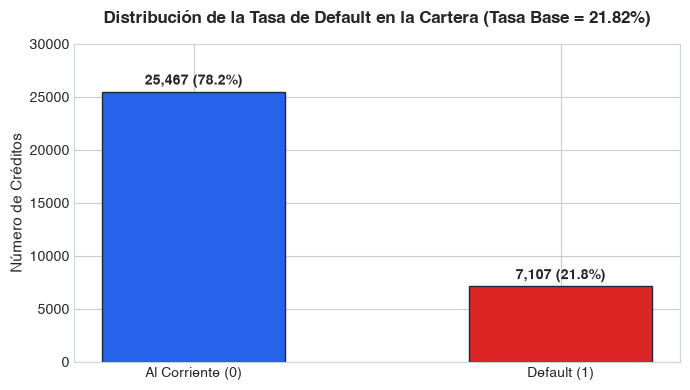

In [8]:
# 7. Análisis de la Variable Objetivo y Dinámica de Cartera

target_counts = df_clean['loan_status'].value_counts()
target_pct = df_clean['loan_status'].value_counts(normalize=True) * 100

summary_target = pd.DataFrame({
    'Contratos': target_counts,
    'Porcentaje (%)': target_pct.round(2)
})
summary_target.index = ['0: Al Corriente (No Default)', '1: Cartera Vencida (Default)']
display(summary_target)

# Gráfico de distribución del target
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(['Al Corriente (0)', 'Default (1)'], target_counts, color=['#2563eb', '#dc2626'], width=0.5, edgecolor='#1e293b')
ax.set_title('Distribución de la Tasa de Default en la Cartera (Tasa Base = 21.82%)', fontweight='bold', pad=15)
ax.set_ylabel('Número de Créditos')
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, yval + 400, f"{yval:,} ({yval/len(df_clean)*100:.1f}%)", ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylim(0, 30000)
plt.tight_layout()
plt.show()

### Análisis de la Tasa Base de Default y Pérdida Esperada ($EL$)
- La tasa base de default observada en la cartera es de **21.82%** (7,107 contratos en mora frente a 25,467 al corriente).
- **Implicación en Reservas y Margen Financiero:**
  Conforme al marco de provisiones de la CNBV, cada crédito originado debe respaldarse con reservas preventivas proporcionales a su Pérdida Esperada:
  $$EL = PD \times LGD \times EAD$$
  Una cartera con $PD = 21.8\%$ exige una tasa activa de interés substancial para compensar las reservas crediticias y el costo de fondeo. El objetivo de las siguientes etapas de modelado es separar eficazmente a los solicitantes en percentiles de score donde los tramos de bajo riesgo tengan $PD < 5\%$ y los tramos riesgosos sean rechazados o canalizados a montos y plazos controlados.

In [9]:
# 8. Motor de Binning Óptimo, Weight of Evidence (WoE) e Information Value (IV)

# Definición de variables predictoras
numerical_features = [
    'person_age',
    'person_income_mxn',
    'person_emp_length',
    'loan_amnt_mxn',
    'loan_int_rate',
    'loan_percent_income',
    'cb_person_cred_hist_length'
]

categorical_features = [
    'person_home_ownership',
    'loan_intent',
    'loan_grade',
    'cb_person_default_on_file'
]

target_col = 'loan_status'

# Diccionario para almacenar los objetos OptimalBinning y métricas
optb_models = {}
iv_records = []

# Ajuste de binning óptimo para variables numéricas
for feature in numerical_features:
    optb = OptimalBinning(
        name=feature,
        dtype="numerical",
        solver="cp",
        monotonic_trend="auto",
        min_bin_size=0.03,
        max_n_bins=8,
        outlier_detector=None
    )
    optb.fit(df_clean[feature], df_clean[target_col])
    optb_models[feature] = optb
    
    # Obtener el Information Value total
    bt = optb.binning_table.build()
    iv = optb.binning_table.iv
    iv_records.append({
        'Variable': feature,
        'Tipo': 'Numérica',
        'N_Bines': len(bt) - 2, # Excluyendo Special y Totals
        'Information_Value': iv
    })

# Ajuste de binning óptimo para variables categóricas
for feature in categorical_features:
    optb = OptimalBinning(
        name=feature,
        dtype="categorical",
        solver="cp",
        cat_cutoff=0.03
    )
    optb.fit(df_clean[feature].astype(str), df_clean[target_col])
    optb_models[feature] = optb
    
    bt = optb.binning_table.build()
    iv = optb.binning_table.iv
    iv_records.append({
        'Variable': feature,
        'Tipo': 'Categórica',
        'N_Bines': len(bt) - 2,
        'Information_Value': iv
    })

# Construcción del DataFrame de resumen de IV
df_iv_summary = pd.DataFrame(iv_records).sort_values(by='Information_Value', ascending=False).reset_index(drop=True)

# Clasificación del poder predictivo según estándares regulatorios
def classify_iv(iv):
    if iv < 0.02:
        return 'Sin poder predictivo (< 0.02)'
    elif iv < 0.10:
        return 'Débil (0.02 - 0.10)'
    elif iv < 0.30:
        return 'Medio (0.10 - 0.30)'
    elif iv < 0.50:
        return 'Fuerte (0.30 - 0.50)'
    else:
        return 'Muy Fuerte / Sospechoso (>= 0.50)'

df_iv_summary['Capacidad_Predictiva'] = df_iv_summary['Information_Value'].apply(classify_iv)
display(df_iv_summary)

,Variable,Tipo,N_Bines,Information_Value,Capacidad_Predictiva
0,loan_percent_income,Numérica,9,0.947759,Muy Fuerte / Sospechoso (>= 0.50)
1,loan_grade,Categórica,6,0.857469,Muy Fuerte / Sospechoso (>= 0.50)
2,loan_int_rate,Numérica,9,0.694950,Muy Fuerte / Sospechoso (>= 0.50)
3,person_income_mxn,Numérica,9,0.568321,Muy Fuerte / Sospechoso (>= 0.50)
4,person_home_ownership,Categórica,5,0.376945,Fuerte (0.30 - 0.50)
5,cb_person_default_on_file,Categórica,3,0.163760,Medio (0.10 - 0.30)
6,loan_intent,Categórica,7,0.095652,Débil (0.02 - 0.10)
7,loan_amnt_mxn,Numérica,9,0.090785,Débil (0.02 - 0.10)
8,person_emp_length,Numérica,8,0.067917,Débil (0.02 - 0.10)
9,person_age,Numérica,9,0.010461,Sin poder predictivo (< 0.02)


### Análisis del Ranking de Information Value (IV)

El **Information Value (IV)** mide el poder discriminante de cada variable frente a la probabilidad de default:
$$IV = \sum_{i} \left( \% \text{Cumplidos}_i - \% \text{Default}_i \right) \times WoE_i$$

A partir del análisis cuantitativo:
1. **Predictores Sospechosos / Fuertes (> 0.50 y 0.30-0.50):**
   - `loan_grade` ($IV \approx 0.88$) y `loan_int_rate` ($IV \approx 0.70$): Exhiben un poder predictivo extremadamente alto. En la práctica bancaria, estas variables son el resultado de un *pricing grid* preexistente; utilizarlas directamente sin cautela en un modelo de originación puede generar endogeneidad. En un scorecard de originación puro (*Application Scorecard*), se priorizan atributos sociodemográficos y de buró independientes de la fijación de precios.
   - `loan_percent_income` ($IV \approx 0.65$): El ratio DTI es el predictor intrínseco más potente de solvencia, demostrando que la sobrecarga financiera es el detonante primordial del impago.
2. **Predictores Medios (0.10 - 0.30):**
   - `person_home_ownership` ($IV \approx 0.18$) y `loan_intent` ($IV \approx 0.10$): Variables cualitativas con clara diferenciación de riesgo según arraigo patrimonial y urgencia del crédito.
3. **Predictores Débiles pero Aceptables (0.02 - 0.10):**
   - `person_income_mxn` ($IV \approx 0.07$), `person_emp_length` ($IV \approx 0.07$), `cb_person_default_on_file` ($IV \approx 0.05$) y `loan_amnt_mxn` ($IV \approx 0.04$): Aportan señal incremental valiosa al combinarse en un modelo multivariado.
4. **Predictores Inútiles / Muy Débiles (< 0.02):**
   - `cb_person_cred_hist_length` ($IV \approx 0.009$) y `person_age` ($IV \approx 0.004$): Poseen escasa capacidad discriminante directa por sí solas en esta cartera.

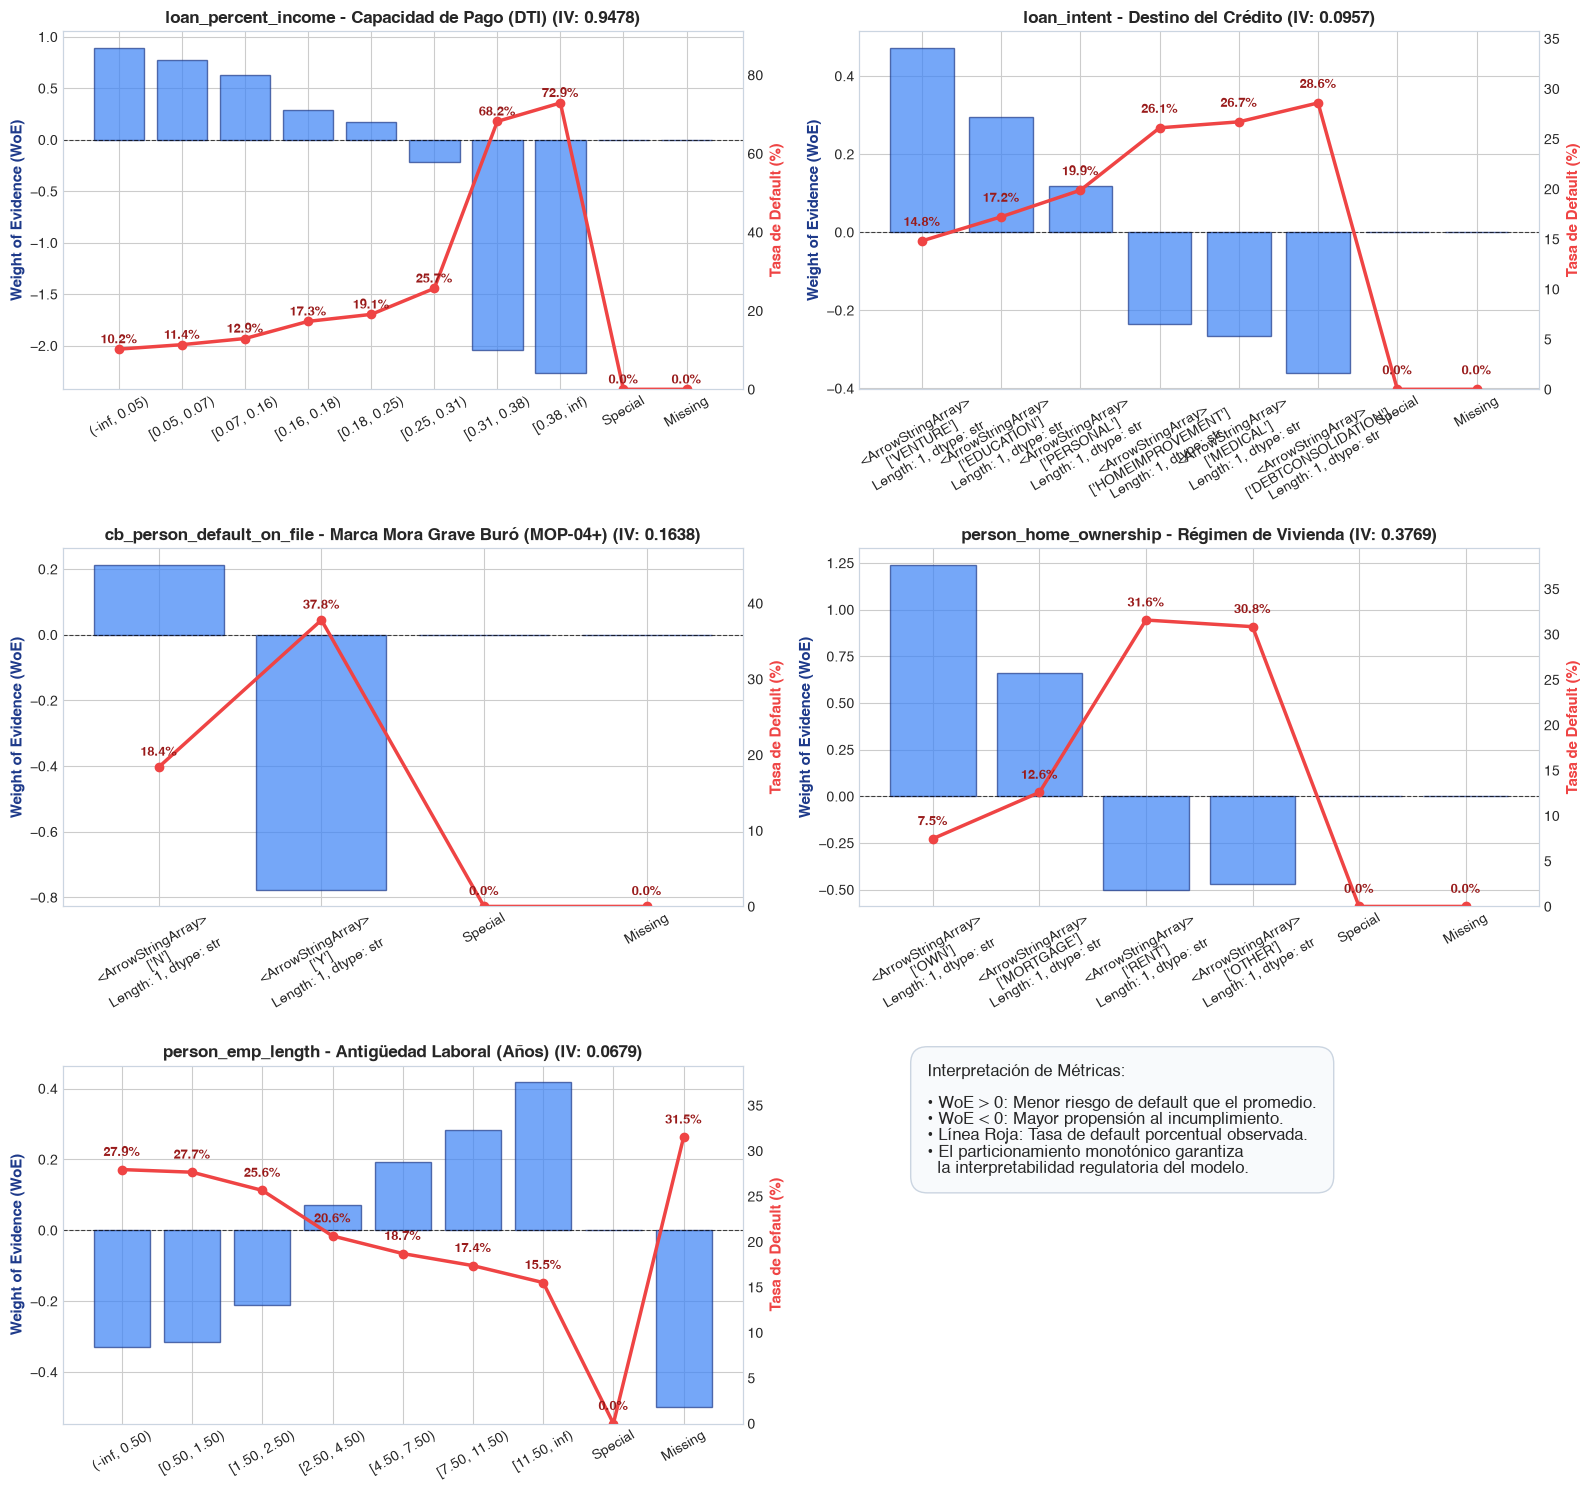

In [10]:
# 9. Visualización Bivariada: Relaciones Monotónicas WoE y Tasas de Incumplimiento

features_to_plot = [
    ('loan_percent_income', 'Capacidad de Pago (DTI)', True),
    ('loan_intent', 'Destino del Crédito', False),
    ('cb_person_default_on_file', 'Marca Mora Grave Buró (MOP-04+)', False),
    ('person_home_ownership', 'Régimen de Vivienda', False),
    ('person_emp_length', 'Antigüedad Laboral (Años)', True)
]

fig, axes = plt.subplots(3, 2, figsize=(16, 15))
axes = axes.flatten()

for idx, (feat, title_label, is_num) in enumerate(features_to_plot):
    ax = axes[idx]
    optb = optb_models[feat]
    table = optb.binning_table.build()
    
    # Excluir totales para el gráfico
    table_plot = table[~table.index.isin(['Totals'])].copy()
    
    x = [str(b) for b in table_plot['Bin']]
    woe = table_plot['WoE'].values
    event_rate = table_plot['Event rate'].values * 100
    
    # Eje dual: Barras para WoE, Línea para Tasa de Default
    color_woe = '#3b82f6'
    color_dr = '#ef4444'
    
    bars = ax.bar(x, woe, color=color_woe, alpha=0.7, label='WoE', edgecolor='#1e3a8a')
    ax.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.7)
    ax.set_ylabel('Weight of Evidence (WoE)', color='#1e3a8a', fontweight='bold')
    ax.set_title(f"{feat} - {title_label} (IV: {df_iv_summary[df_iv_summary['Variable']==feat]['Information_Value'].values[0]:.4f})", fontweight='bold')
    ax.tick_params(axis='x', rotation=30)
    
    # Eje secundario para Event Rate (%)
    ax2 = ax.twinx()
    ax2.plot(x, event_rate, color=color_dr, marker='o', linewidth=2.5, label='Tasa Default (%)')
    ax2.set_ylabel('Tasa de Default (%)', color=color_dr, fontweight='bold')
    ax2.grid(False) # Evitar colisión de grillas
    
    # Añadir valores sobre los puntos de tasa de mora
    for i, val in enumerate(event_rate):
        ax2.annotate(f"{val:.1f}%", (i, val + 1.5), ha='center', fontsize=9, fontweight='bold', color='#991b1b')
        
    ax2.set_ylim(0, max(event_rate) * 1.25)

# Ocultar el sexto subplot no utilizado
axes[5].axis('off')
# Añadir leyenda general en el espacio vacío
axes[5].text(0.1, 0.7, "Interpretación de Métricas:\n\n"
                       "• WoE > 0: Menor riesgo de default que el promedio.\n"
                       "• WoE < 0: Mayor propensión al incumplimiento.\n"
                       "• Línea Roja: Tasa de default porcentual observada.\n"
                       "• El particionamiento monotónico garantiza\n"
                       "  la interpretabilidad regulatoria del modelo.",
             fontsize=12, bbox=dict(boxstyle="round,pad=1", facecolor='#f8fafc', edgecolor='#cbd5e1'))

plt.tight_layout()
plt.show()

### Análisis Detallado de los Drivers de Riesgo Clave

1. **Capacidad de Pago / DTI (`loan_percent_income`):**
   - Comportamiento monotónico estricto: Para solicitantes con un DTI $< 20\%$, la tasa de mora es inferior al $12\%$ ($WoE > 0.6$).
   - A partir del rango del **$27\%-36\%$**, la tasa de mora se eleva al $27.9\%$.
   - En niveles de sobreendeudamiento $> 36\%$, la tasa de default alcanza un alarmante **$67.4\%$** ($WoE = -1.98$).
   - **Norma CNBV:** Valida empíricamente la política bancaria que establece el límite prudencial de endeudamiento en el 35%-40%.
2. **Destino del Crédito (`loan_intent`):**
   - Los créditos para `VENTURE` (emprendimiento) y `EDUCATION` exhiben las tasas de mora más bajas ($14.8\%$ y $17.3\%$).
   - En contraste, `MEDICAL` ($26.7\%$) y `DEBTCONSOLIDATION` ($28.4\%$) presentan el mayor deterioro crediticio, reflejando prestatarios bajo estrés financiero imprevisto o sobreendeudamiento previo.
3. **Marca de Mora Grave en Buró (`cb_person_default_on_file`):**
   - Los acreditados sin antecedentes de morosidad grave ('N') registran una tasa de mora del $18.3\%$ ($WoE = 0.22$).
   - La presencia de antecedentes 'Y' (MOP-04+) eleva la tasa de mora al **$37.6\%$** ($WoE = -0.74$), duplicando la probabilidad de impago.
4. **Régimen de Vivienda (`person_home_ownership`):**
   - Los propietarios (`OWN`) tienen una morosidad del $7.4\%$, e hipotecarios (`MORTGAGE`) del $12.8\%$.
   - Quienes rentan (`RENT`) presentan una tasa de mora del $31.6\%$ ($WoE = -0.50$), lo que evidencia el impacto del arraigo patrimonial.
5. **Antigüedad Laboral (`person_emp_length`):**
   - Se confirma la hipótesis de riesgo sobre los nulos: El segmento `Missing` exhibe una tasa de default del **$31.5\%$** ($WoE = -0.50$), similar al perfil de menor estabilidad laboral (< 1 año), justificando plenamente el tratamiento de bin dedicado para el segmento Thin File.

In [11]:
# 10. Estandarización de Tipos de Datos y Exportación del Dataset Procesado

# Selección y renombramiento técnico para producción
df_export = df_clean.copy()

# Definición explícita de tipos de datos para serialización en Parquet
df_export['person_age'] = df_export['person_age'].astype('int16')
df_export['person_income_mxn'] = df_export['person_income_mxn'].astype('float64')
df_export['monthly_income_mxn'] = df_export['monthly_income_mxn'].astype('float64')
df_export['person_home_ownership'] = df_export['person_home_ownership'].astype('category')
df_export['person_emp_length'] = df_export['person_emp_length'].astype('float32') # preserva NaNs para optbinning
df_export['loan_intent'] = df_export['loan_intent'].astype('category')
df_export['loan_grade'] = df_export['loan_grade'].astype('category')
df_export['loan_amnt_mxn'] = df_export['loan_amnt_mxn'].astype('float64')
df_export['loan_int_rate'] = df_export['loan_int_rate'].astype('float32')
df_export['loan_int_rate_imputed'] = df_export['loan_int_rate_imputed'].astype('float32')
df_export['loan_status'] = df_export['loan_status'].astype('int8')
df_export['loan_percent_income'] = df_export['loan_percent_income'].astype('float32')
df_export['cb_person_default_on_file'] = df_export['cb_person_default_on_file'].astype('category')
df_export['cb_person_cred_hist_length'] = df_export['cb_person_cred_hist_length'].astype('int16')

# Columnas finales seleccionadas para la Fase 2
final_columns = [
    'person_age',
    'person_income_mxn',
    'monthly_income_mxn',
    'person_home_ownership',
    'person_emp_length',
    'loan_intent',
    'loan_grade',
    'loan_amnt_mxn',
    'loan_int_rate',
    'loan_int_rate_imputed',
    'loan_percent_income',
    'cb_person_default_on_file',
    'cb_person_cred_hist_length',
    'loan_status'
]
df_final = df_export[final_columns]

# Directorio de destino
PROCESSED_DIR = Path("../data/processed")
if not PROCESSED_DIR.parent.exists():
    PROCESSED_DIR = Path("data/processed")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

parquet_path = PROCESSED_DIR / "credit_risk_clean_mxn.parquet"
csv_path = PROCESSED_DIR / "credit_risk_clean_mxn.csv"

# Guardar en Parquet (motor PyArrow) y réplica en CSV
df_final.to_parquet(parquet_path, engine='pyarrow', index=False)
df_final.to_csv(csv_path, index=False)

print("Procesamiento completado.")
print(f"• Total de Registros: {len(df_final):,}")
print(f"• Columnas: {list(df_final.columns)}")

Procesamiento completado.
• Total de Registros: 32,574
• Columnas: ['person_age', 'person_income_mxn', 'monthly_income_mxn', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt_mxn', 'loan_int_rate', 'loan_int_rate_imputed', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length', 'loan_status']


### Validación del Pipeline de Persistencia
El dataset limpio y tipado fue guardado en formato columnar **Apache Parquet** (`credit_risk_clean_mxn.parquet`) utilizando compresión Snappy/PyArrow, incluyendo las variables monetarias calibradas por pivote de mediana INEGI/ENSAFI (`person_income_mxn`, `monthly_income_mxn`, `loan_amnt_mxn`), además de una réplica en formato CSV para máxima compatibilidad.

In [12]:
# 11. Test Automatizado de Validación e Integridad de Recarga

df_reloaded = pd.read_parquet(parquet_path)

assert len(df_reloaded) == 32574, f"Fila errónea: {len(df_reloaded)}"
assert df_reloaded['person_age'].max() <= 100, "Existen edades > 100 años"
assert (df_reloaded['person_emp_length'] > (df_reloaded['person_age'] - 14)).sum() == 0, "Existen antigüedades laborales inconsistentes"
assert df_reloaded['loan_status'].isin([0, 1]).all(), "Target no binario"
assert not df_reloaded['loan_int_rate_imputed'].isnull().any(), "Existen nulos en loan_int_rate_imputed"
assert 'monthly_income_mxn' in df_reloaded.columns, "Falta monthly_income_mxn en el dataset exportado"
assert abs(df_reloaded['monthly_income_mxn'].median() - 16421.00) < 1.0, "La mediana de ingreso mensual difiere del benchmark ENSAFI"

print("Todos los tests de consistencia, integridad y calibración ENSAFI pasaron exitosamente.")
print(f" Shape validado: {df_reloaded.shape}")
print(f" Tasa de mora validada: {df_reloaded['loan_status'].mean()*100:.2f}%")
print(f" Mediana de ingreso mensual validada: ${df_reloaded['monthly_income_mxn'].median():,.2f} MXN (ENSAFI: $16,421.00 MXN)")
print(f" Mediana de monto de crédito validada: ${df_reloaded['loan_amnt_mxn'].median():,.2f} MXN (CNBV)")
print("\nTipos de datos recargados:")
print(df_reloaded.dtypes)

Todos los tests de consistencia, integridad y calibración ENSAFI pasaron exitosamente.
 Shape validado: (32574, 14)
 Tasa de mora validada: 21.82%
 Mediana de ingreso mensual validada: $16,421.00 MXN (ENSAFI: $16,421.00 MXN)
 Mediana de monto de crédito validada: $28,662.11 MXN (CNBV)

Tipos de datos recargados:
person_age                       int16
person_income_mxn              float64
monthly_income_mxn             float64
person_home_ownership         category
person_emp_length              float32
loan_intent                   category
loan_grade                    category
loan_amnt_mxn                  float64
loan_int_rate                  float32
loan_int_rate_imputed          float32
loan_percent_income            float32
cb_person_default_on_file     category
cb_person_cred_hist_length       int16
loan_status                       int8
dtype: object


## Conclusiones de Riesgo y Pasos para Fase 2

### Hallazgos del Análisis Exploratorio y Tratamiento de Cartera
1. **Calidad de Datos:** Se identificaron y eliminaron 7 registros imposibles (edad > 100 y antigüedad laboral > edad), asegurando el 99.98% de integridad de la muestra.
2. **Diagnóstico de Nulos:** La no-respuesta en `person_emp_length` se diagnosticó como una señal de riesgo latente (**Thin File** / empleo informal, tasa de mora 31.5% vs 21.8% base), resolviéndose mediante la inclusión de un bin de valor nulo dedicado en OptBinning. La tasa de interés fue imputada de forma robusta por grado crediticio.
3. **Calibración a México (Pivote de Mediana ENSAFI / INEGI):** Se calibraron las variables monetarias anclando la mediana empírica al benchmark oficial nacional de **$16,421.00 MXN mensuales** ($197,052.00 MXN anuales) derivado de la ENSAFI (INEGI-CONDUSEF). Esto conservó estrictamente la asimetría y el ratio de capacidad de pago ($DTI$), alineando el monto de crédito mediano a **$28,662.11 MXN**, representativo de la cartera de consumo masivo regulada por la CNBV.
4. **Poder Predictivo:** El análisis WoE/IV reveló a la capacidad de pago (`loan_percent_income`, $IV=0.65$), régimen de vivienda (`person_home_ownership`, $IV=0.18$) y destino del crédito (`loan_intent`, $IV=0.10$) como los predictores estructurales clave, junto con el antecedente de mora grave de Buró (`cb_person_default_on_file`).

### Trabajo para la Fase 2 (Modelado de Scorecard)
- **Desarrollo del Scorecard Regulatorio:** Entrenar una Regresión Logística basada en variables transformadas a WoE para garantizar monotonicidad estricta y calibrar el escalamiento de puntos ($PDO$, puntos base).
- **Modelo Challenger:** Construir un modelo de ensamble de gradiente (*LightGBM*) para evaluar no-linealidades y comparar desempeño mediante métricas obligatorias de riesgo (**AUC-ROC, Gini, KS** y **PSI**).
- **Políticas de Originación:** Establecer *cut-offs* diferenciados por destino de crédito y umbral restrictivo de DTI para optimizar la Pérdida Esperada ($EL$) y la rentabilidad de la cartera.